In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载数据集并输出头部信息
data = pd.read_csv("A地区的天气数据.csv")
print(data.head())

          日期  平均温度 (°F)  平均湿度 (%)  平均露点(°F)  平均气压（英寸）  平均风速（mph）  平均阵风速度（mph）  \
0  7/28/2020       60.5        61      45.3      29.7        4.0          6.2   
1  7/27/2020       61.7        64      47.4      29.9        2.2          4.0   
2  7/26/2020       60.6        68      48.9      29.8        1.7          2.9   
3  7/25/2020       62.8        60      48.1      29.7        2.5          4.0   
4  7/24/2020       64.1        62      49.8      29.6        3.6          5.8   

   平均方向（°deg）  月降水量（in）年  降水量（in ）  ...  最高湿度（％）  最低湿度（％）    最高压力    最低压力  \
0         248       0.35      4.49  ...       94       35  29.792  29.675   
1          66       0.33      4.47  ...       96       35  29.941  29.781   
2         357       0.33      4.47  ...       90       40  29.930  29.745   
3         242       0.33      4.47  ...       90       36  29.781  29.645   
4         240       0.24      4.38  ...       86       35  29.686  29.577   

   最大风速（mph）  最大阵风速度（mph）  最大热量指数（°F）       日期.1  

In [17]:
# 2. 计算2009年1-11月份的每月的平均压力差，并按照平均压力差从大到小排序
data['日期'] = pd.to_datetime(data['日期'])

data_2009 = data[data['日期'].dt.year == 2009]

monthly_pressure_diff = data_2009.groupby('月份')['压力差'].mean().sort_values(ascending=False)
print(monthly_pressure_diff)


月份
11    0.419700
9     0.399633
1     0.384710
3     0.374786
10    0.364677
4     0.347300
2     0.339929
5     0.300258
6     0.245133
8     0.242258
7     0.230935
Name: 压力差, dtype: float64


C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabt

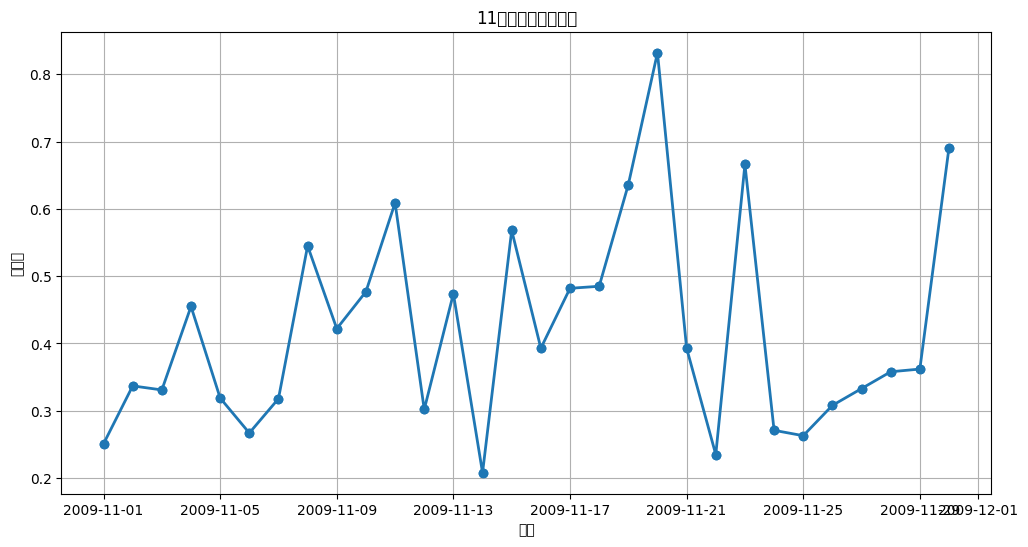

In [18]:
max_pressure_diff_month = monthly_pressure_diff.index[0]

data_month = data_2009[data_2009['月份'] == max_pressure_diff_month]
data_month = data_month.sort_values(by='日期') 


plt.figure(figsize=(12, 6))  # 设置图形的宽度和高度
plt.plot(data_month['日期'], data_month['压力差'], marker='o', linestyle='-', linewidth=2)  # 绘制折线图并添加数据点
plt.scatter(data_month['日期'], data_month['压力差'])  # 添加数据点
plt.xlabel('日期')
plt.ylabel('压力差')
plt.title(f'{max_pressure_diff_month}月份每天的压力差')
plt.grid(True)  # 添加网格
plt.show()